# Weather Data Analysis & Rain Prediction
This notebook performs:
1. Data Cleaning and Imputation
2. Feature Engineering
3. Exploratory Data Analysis (EDA)
4. Temporal Analysis of Rain Patterns
5. Correlation Analysis
6. Machine Learning Model Training and Evaluation


## Load Dataset
Reading CSV data, converting DATE column to datetime, sorting, and selecting relevant columns.

## Filter Date Range
Selecting records between 2023-01-01 and 2025-06-01 for analysis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("weather.csv")
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

keep_cols = [
    
    "DATE", "PRCP", "TAVG", "TMAX", "TMIN", "AWND",
    "SNOW", "SNWD",
    "WT01", "WT02", "WT03", "WT04", "WT05", "WT06", "WT08",
    "WDF2", "WDF5", "WSF2", "WSF5", 
]
df = df[keep_cols]

# Filter the required date range (2023-01-01 to 2025-06-01)
start_date = pd.to_datetime("2023-01-01")
end_date   = pd.to_datetime("2025-06-01")

df = df[(df["DATE"] >= start_date) & (df["DATE"] <= end_date)].reset_index(drop=True)
df.head()

,DATE,PRCP,TAVG,TMAX,TMIN,AWND,SNOW,SNWD,WT01,WT02,WT03,WT04,WT05,WT06,WT08,WDF2,WDF5,WSF2,WSF5
0,2023-01-01,0.00,NaN,55,49,4.92,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,310.0,250.0,13.0,18.1
1,2023-01-02,0.02,NaN,56,49,3.58,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,230.0,240.0,10.1,16.1
2,2023-01-03,0.42,NaN,58,47,3.13,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,250.0,250.0,8.9,15.0
3,2023-01-04,0.02,NaN,66,49,4.47,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,240.0,240.0,13.0,21.9
4,2023-01-05,0.01,NaN,50,44,5.14,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,60.0,50.0,13.0,15.0


## Temperature Imputation
Fill missing TAVG values with the average of TMAX and TMIN.

## Weekly Average Imputation
For PRCP, TAVG, TMAX, TMIN, AWND, SNOW, SNWD, WDF2, WDF5, WSF2, WSF5: 
Missing values are filled by the weekly average. If the week is entirely missing, fill with overall mean.

## Weather Event Imputation
For WT01-WT08 flags, missing values are treated as 0.
Columns with almost all missing values (WT06, WT08) are dropped.

## Create Temporal Features
Extract Month, DayOfYear, Year from DATE column.


In [5]:
# If TAVG is missing, replace it with (TMAX + TMIN) / 2
mask_tavg_na = df["TAVG"].isna()
df.loc[mask_tavg_na, "TAVG"] = df.loc[mask_tavg_na, ["TMAX","TMIN"]].mean(axis=1)

# Weekly average imputation for all variables
# Missing values are replaced by the mean of the same Year–Week
# If an entire week is missing, we later replace with column mean

df["YearWeek"] = df["DATE"].dt.strftime("%Y-%U")
cols_to_fill = [
    "PRCP", "TAVG", "TMAX", "TMIN", "AWND",
     "SNOW", "SNWD", "WDF2", "WDF5", "WSF2", "WSF5"
]

# Apply weekly mean imputation
for col in cols_to_fill:
    df[col] = df[col].astype(float)
    df[col] = df.groupby("YearWeek")[col].transform(
        lambda x: x.fillna(x.mean())
    )

# If any value is still NaN (whole-week missing), fill with overall column mean
for col in cols_to_fill:
    df[col] = df[col].fillna(df[col].mean())

wt_cols = ["WT01", "WT02", "WT03", "WT04", "WT05", "WT06", "WT08"]

# Weather event WTxx: Missing is treated as 0
for col in wt_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)
        
df.head()

,DATE,PRCP,TAVG,TMAX,TMIN,AWND,SNOW,SNWD,WT01,WT02,WT03,WT04,WT05,WT06,WT08,WDF2,WDF5,WSF2,WSF5,YearWeek
0,2023-01-01,0.00,52.0,55.0,49.0,4.92,0.0,0.0,1,0,0,0,0,0,0,310.0,250.0,13.0,18.1,2023-01
1,2023-01-02,0.02,52.5,56.0,49.0,3.58,0.0,0.0,0,0,0,0,0,0,0,230.0,240.0,10.1,16.1,2023-01
2,2023-01-03,0.42,52.5,58.0,47.0,3.13,0.0,0.0,1,0,0,0,0,0,1,250.0,250.0,8.9,15.0,2023-01
3,2023-01-04,0.02,57.5,66.0,49.0,4.47,0.0,0.0,1,0,0,0,0,0,0,240.0,240.0,13.0,21.9,2023-01
4,2023-01-05,0.01,47.0,50.0,44.0,5.14,0.0,0.0,1,0,0,0,0,0,1,60.0,50.0,13.0,15.0,2023-01


In [6]:
df["DATE"] = pd.to_datetime(df["DATE"])
df["YearWeek"] = df["DATE"].dt.strftime("%Y-%U")

for col in cols_to_fill:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df.groupby("YearWeek")[col].transform(
        lambda x: x.fillna(x.mean())
    )

# Fill remaining NaNs (entire week missing)
for col in cols_to_fill:
    df[col] = df[col].fillna(df[col].mean())
wt_cols = ["WT01", "WT02", "WT03", "WT04", "WT05", "WT06", "WT08"]

for col in wt_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)
drop_cols = ["WT06", "WT08"]  # fully or nearly empty
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
df["Month"] = df["DATE"].dt.month
df["DayOfYear"] = df["DATE"].dt.dayofyear

## Define Target Variable: RainTomorrow
RainTomorrow is 1 if PRCP > 0 on the next day, else 0.


In [8]:
df["RainTomorrow"] = (df["PRCP"].shift(-1) > 0).astype(int)
df.dropna(inplace=True)

In [9]:
df["PRCP_lag1"] = df["PRCP"].shift(1)
df["TAVG_lag1"] = df["TAVG"].shift(1)

df["RainYesterday"] = (df["PRCP_lag1"] > 0).astype(int)

df.dropna(inplace=True)


In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [11]:
df.head()
df.tail()
df.shape
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
Index: 882 entries, 1 to 882
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   DATE           882 non-null    datetime64[ns]
 1   PRCP           882 non-null    float64       
 2   TAVG           882 non-null    float64       
 3   TMAX           882 non-null    float64       
 4   TMIN           882 non-null    float64       
 5   AWND           882 non-null    float64       
 6   SNOW           882 non-null    float64       
 7   SNWD           882 non-null    float64       
 8   WT01           882 non-null    int64         
 9   WT02           882 non-null    int64         
 10  WT03           882 non-null    int64         
 11  WT04           882 non-null    int64         
 12  WT05           882 non-null    int64         
 13  WDF2           882 non-null    float64       
 14  WDF5           882 non-null    float64       
 15  WSF2           882 non-null 

,DATE,PRCP,TAVG,TMAX,TMIN,AWND,SNOW,SNWD,WT01,WT02,...,WDF5,WSF2,WSF5,YearWeek,Month,DayOfYear,RainTomorrow,PRCP_lag1,TAVG_lag1,RainYesterday
count,882,882.000000,882.000000,882.000000,882.000000,882.00000,882.000000,882.000000,882.000000,882.000000,...,882.000000,882.000000,882.000000,882,882.000000,882.000000,882.000000,882.000000,882.000000,882.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,129,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2024-11,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN
mean,2024-03-17 12:00:00,0.140839,55.983560,62.988662,48.978458,5.01167,0.025737,0.057370,0.360544,0.031746,...,190.938776,13.881463,23.479932,NaN,5.925170,165.060091,0.339002,0.140839,55.976757,0.340136
min,2023-01-02 00:00:00,0.000000,15.000000,19.000000,3.000000,0.67000,0.000000,0.000000,0.000000,0.000000,...,10.000000,6.000000,8.900000,NaN,1.000000,1.000000,0.000000,0.000000,15.000000,0.000000
25%,2023-08-10 06:00:00,0.000000,44.000000,50.000000,37.000000,3.13000,0.000000,0.000000,0.000000,0.000000,...,90.000000,10.100000,18.100000,NaN,3.000000,74.250000,0.000000,0.000000,44.000000,0.000000
50%,2024-03-17 12:00:00,0.000000,55.500000,63.000000,48.000000,4.70000,0.000000,0.000000,0.000000,0.000000,...,220.000000,13.000000,21.900000,NaN,5.000000,148.000000,0.000000,0.000000,55.250000,0.000000
75%,2024-10-23 18:00:00,0.060000,69.000000,78.000000,62.000000,6.49000,0.000000,0.000000,1.000000,0.000000,...,280.000000,16.100000,28.000000,NaN,9.000000,255.750000,1.000000,0.060000,69.000000,1.000000
max,2025-06-01 00:00:00,5.480000,86.000000,95.000000,79.000000,14.32000,3.200000,3.100000,1.000000,1.000000,...,360.000000,33.100000,68.000000,NaN,12.000000,366.000000,1.000000,5.480000,86.000000,1.000000


In [12]:
weather_flags = ["WT01", "WT02"]

for col in weather_flags:
    df[col] = df[col].astype(int)


In [13]:
print("Remaining missing values:")
print(df.isnull().sum().sort_values(ascending=False).head())

Remaining missing values:
DATE            0
PRCP            0
TAVG_lag1       0
PRCP_lag1       0
RainTomorrow    0
dtype: int64


## Lag Features
- PRCP_lag1: Precipitation yesterday
- TAVG_lag1: Average temperature yesterday
- RainYesterday: 1 if it rained yesterday, else 0


In [15]:
df["PRCP_lag1"] = df["PRCP"].shift(1)
df["TAVG_lag1"] = df["TAVG"].shift(1)
df["RainYesterday"] = df["PRCP_lag1"].fillna(0).apply(lambda x: 1 if x > 0 else 0)

df.dropna(inplace=True)


Datetime features were decomposed into year, month, and day-of-year to preserve temporal patterns while maintaining numerical compatibility. Columns with complete or near-complete missingness were removed due to lack of predictive value. Remaining numerical features were median-imputed to reduce sensitivity to outliers.

In [17]:
# Time-based features

df["Month"] = df["DATE"].dt.month
df["DayOfYear"] = df["DATE"].dt.dayofyear
df["Year"] = df["DATE"].dt.year

# Season mapping
def month_to_season(m):
    if m in [12,1,2]:
        return "Winter"
    elif m in [3,4,5]:
        return "Spring"
    elif m in [6,7,8]:
        return "Summer"
    else:
        return "Fall"

df["Season"] = df["Month"].apply(month_to_season)

df.head()

,DATE,PRCP,TAVG,TMAX,TMIN,AWND,SNOW,SNWD,WT01,WT02,...,WSF5,YearWeek,Month,DayOfYear,RainTomorrow,PRCP_lag1,TAVG_lag1,RainYesterday,Year,Season
2,2023-01-03,0.42,52.5,58.0,47.0,3.13,0.0,0.0,1,0,...,15.0,2023-01,1,3,1,0.02,52.5,1,2023,Winter
3,2023-01-04,0.02,57.5,66.0,49.0,4.47,0.0,0.0,1,0,...,21.9,2023-01,1,4,1,0.42,52.5,1,2023,Winter
4,2023-01-05,0.01,47.0,50.0,44.0,5.14,0.0,0.0,1,0,...,15.0,2023-01,1,5,1,0.02,57.5,1,2023,Winter
5,2023-01-06,0.27,44.0,49.0,39.0,5.37,0.0,0.0,1,0,...,21.0,2023-01,1,6,0,0.01,47.0,1,2023,Winter
6,2023-01-07,0.00,41.0,45.0,37.0,6.71,0.0,0.0,0,0,...,19.9,2023-01,1,7,0,0.27,44.0,1,2023,Winter


In [18]:
df.shape
df["RainTomorrow"].value_counts()
df["RainTomorrow"].value_counts(normalize=True)

RainTomorrow
0    0.661748
1    0.338252
Name: proportion, dtype: float64

In [19]:
df[["PRCP","TAVG","TMAX","TMIN","AWND"]].describe()

,PRCP,TAVG,TMAX,TMIN,AWND
count,881.000000,881.000000,881.000000,881.000000,881.000000
mean,0.140976,55.987514,62.996595,48.978434,5.013295
std,0.397474,15.674489,16.740703,15.001234,2.332644
min,0.000000,15.000000,19.000000,3.000000,0.670000
25%,0.000000,44.000000,50.000000,37.000000,3.130000
50%,0.000000,55.500000,63.000000,48.000000,4.700000
75%,0.060000,69.000000,78.000000,62.000000,6.490000
max,5.480000,86.000000,95.000000,79.000000,14.320000


In [20]:
df.groupby("RainTomorrow")[["PRCP","TAVG","AWND"]].mean()

,PRCP,TAVG,AWND
RainTomorrow,,,
0,0.100875,55.825901,5.116719
1,0.219430,56.303691,4.810960


In [21]:
num_cols = df.select_dtypes(include=np.number).columns


plt.suptitle("Numerical Feature Distributions")
plt.show()

<Figure size 640x480 with 0 Axes>

In [22]:
# One-hot encode Season (drop one category to avoid multicollinearity)
df = pd.get_dummies(df, columns=["Season"], drop_first=True)

# Lag features
df["PRCP_lag1"] = df["PRCP"].shift(1)
df["TAVG_lag1"] = df["TAVG"].shift(1)
df = df.dropna(subset=["PRCP_lag1", "TAVG_lag1"]).reset_index(drop=True)

df.head()

,DATE,PRCP,TAVG,TMAX,TMIN,AWND,SNOW,SNWD,WT01,WT02,...,Month,DayOfYear,RainTomorrow,PRCP_lag1,TAVG_lag1,RainYesterday,Year,Season_Spring,Season_Summer,Season_Winter
0,2023-01-04,0.02,57.5,66.0,49.0,4.47,0.0,0.0,1,0,...,1,4,1,0.42,52.5,1,2023,False,False,True
1,2023-01-05,0.01,47.0,50.0,44.0,5.14,0.0,0.0,1,0,...,1,5,1,0.02,57.5,1,2023,False,False,True
2,2023-01-06,0.27,44.0,49.0,39.0,5.37,0.0,0.0,1,0,...,1,6,0,0.01,47.0,1,2023,False,False,True
3,2023-01-07,0.00,41.0,45.0,37.0,6.71,0.0,0.0,0,0,...,1,7,0,0.27,44.0,1,2023,False,False,True
4,2023-01-08,0.00,37.0,41.0,33.0,4.70,0.0,0.0,0,0,...,1,8,1,0.00,41.0,0,2023,False,False,True


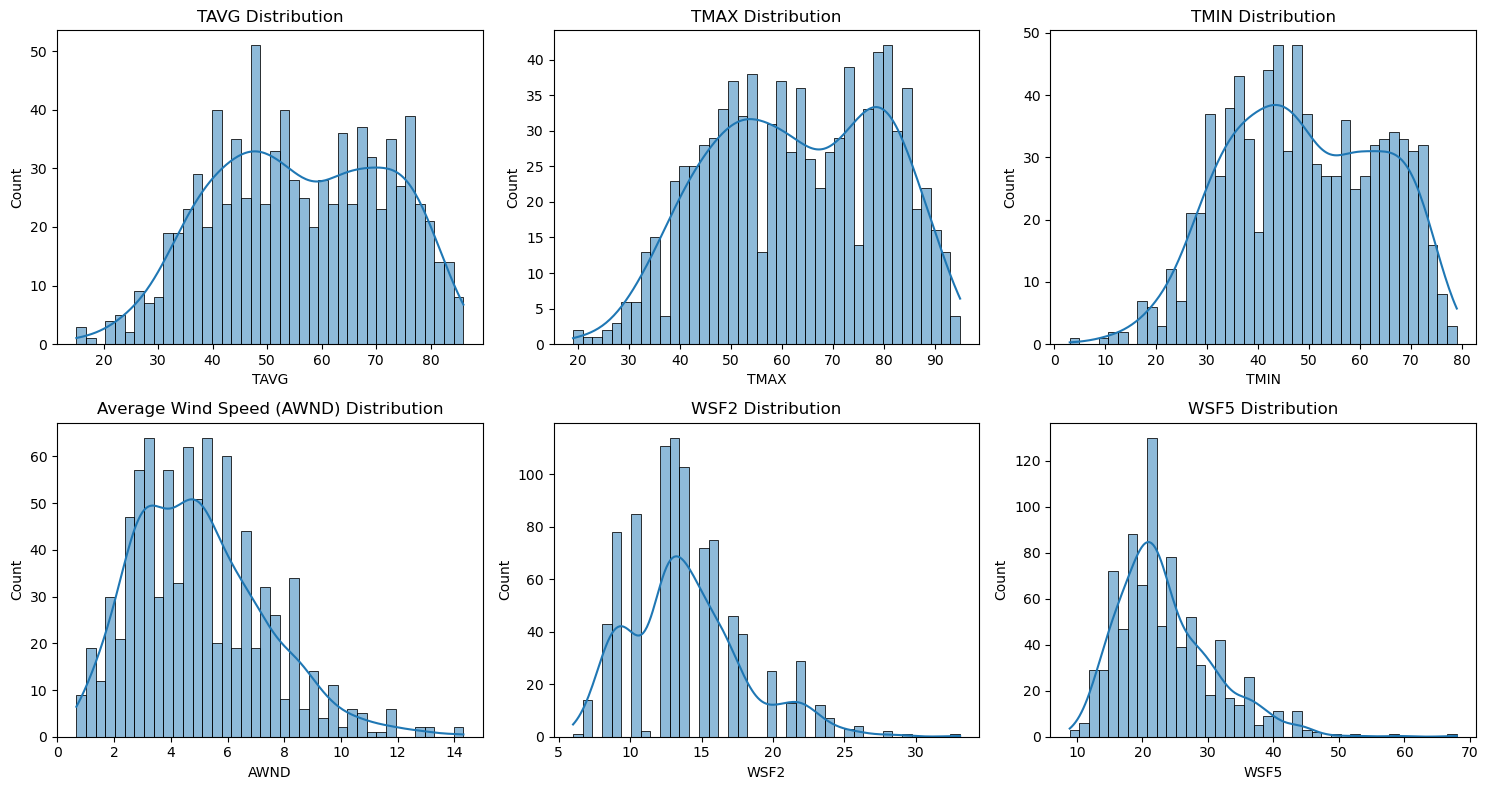

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Temperature distributions
sns.histplot(df["TAVG"], bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("TAVG Distribution")
axes[0, 0].set_xlabel("TAVG")
axes[0, 0].set_ylabel("Count")

sns.histplot(df["TMAX"], bins=40, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("TMAX Distribution")
axes[0, 1].set_xlabel("TMAX")
axes[0, 1].set_ylabel("Count")

sns.histplot(df["TMIN"], bins=40, kde=True, ax=axes[0, 2])
axes[0, 2].set_title("TMIN Distribution")
axes[0, 2].set_xlabel("TMIN")
axes[0, 2].set_ylabel("Count")

# Wind speed distributions
sns.histplot(df["AWND"], bins=40, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Average Wind Speed (AWND) Distribution")
axes[1, 0].set_xlabel("AWND")
axes[1, 0].set_ylabel("Count")

sns.histplot(df["WSF2"], bins=40, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("WSF2 Distribution")
axes[1, 1].set_xlabel("WSF2")
axes[1, 1].set_ylabel("Count")

sns.histplot(df["WSF5"], bins=40, kde=True, ax=axes[1, 2])
axes[1, 2].set_title("WSF5 Distribution")
axes[1, 2].set_xlabel("WSF5")
axes[1, 2].set_ylabel("Count")

plt.tight_layout()


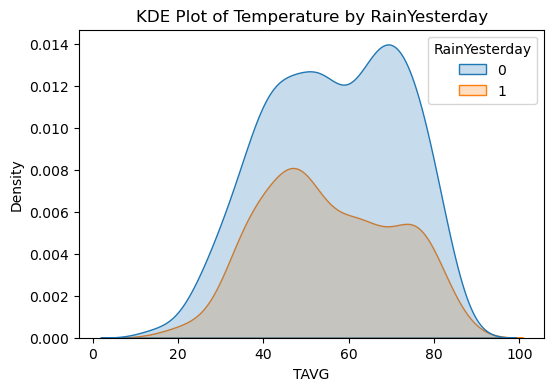

In [24]:
# 7. KDE plot of TAVG by RainToday
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df, x="TAVG", hue="RainYesterday", fill=True)
plt.title("KDE Plot of Temperature by RainYesterday")
plt.xlabel("TAVG")
plt.show()

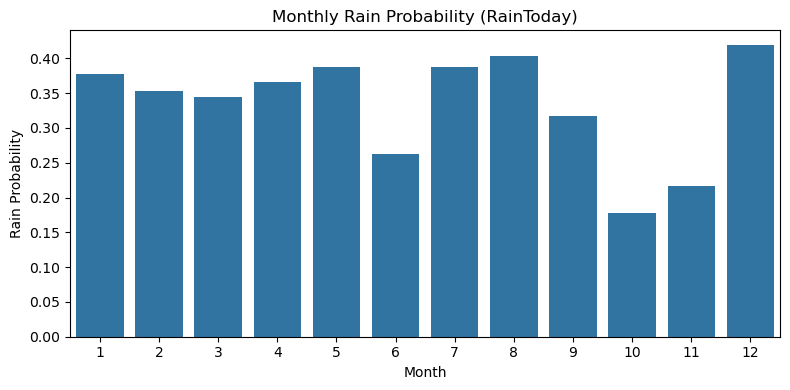

In [25]:
# SECTION 3: Temporal Patterns

# 9. Monthly rain probability (RainToday mean by Month)
monthly_rain = df.groupby("Month")["RainYesterday"].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(x="Month", y="RainYesterday", data=monthly_rain)
plt.title("Monthly Rain Probability (RainToday)")
plt.ylabel("Rain Probability")
plt.tight_layout()

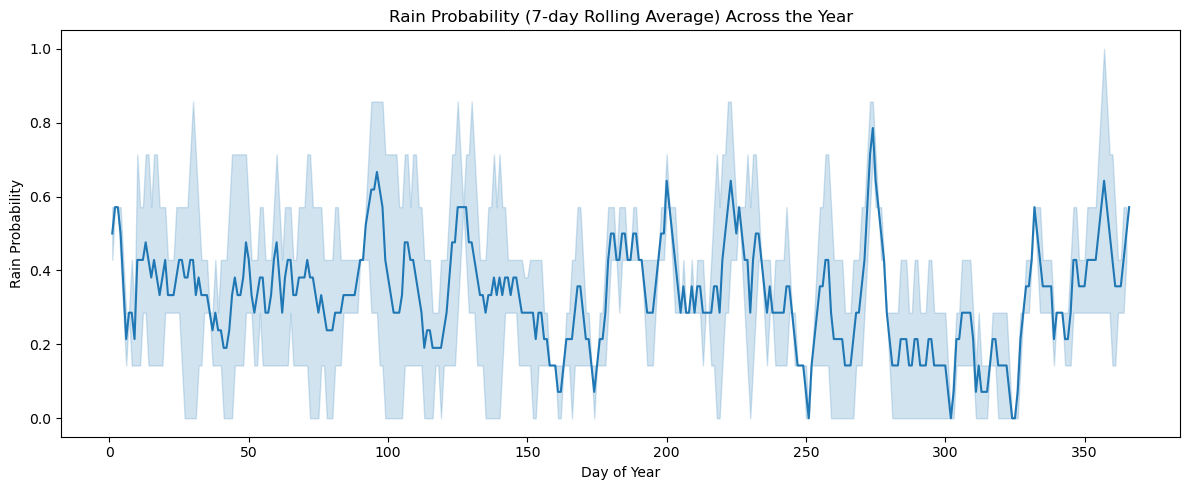

In [26]:
# 10. Rain probability by Day of Year (smoothed line)
df_sorted = df.sort_values("DATE")
# Rolling 7-day average of RainToday
df_sorted["Rain_roll7"] = df_sorted["RainYesterday"].rolling(7).mean()

plt.figure(figsize=(12,5))
sns.lineplot(x="DayOfYear", y="Rain_roll7", data=df_sorted)
plt.title("Rain Probability (7-day Rolling Average) Across the Year")
plt.xlabel("Day of Year")
plt.ylabel("Rain Probability")
plt.tight_layout()
plt.show()

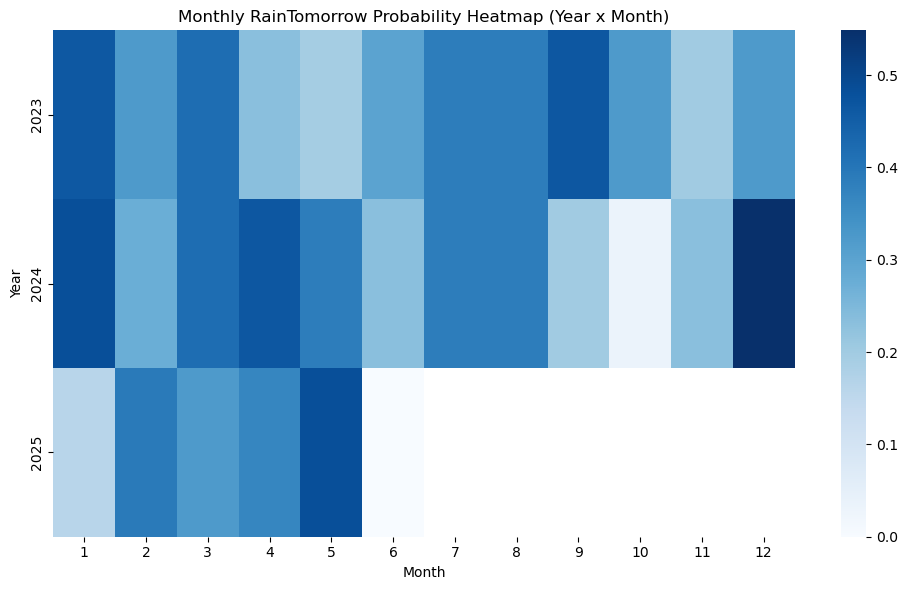

In [27]:
# 11. Year-Month heatmap of rain probability

pivot_month = df.pivot_table(
    values="RainTomorrow",   # ← 改成你现在用的目标
    index="Year",
    columns="Month",
    aggfunc="mean"
).sort_index()

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_month, cmap="Blues", annot=False)
plt.title("Monthly RainTomorrow Probability Heatmap (Year x Month)")
plt.ylabel("Year")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

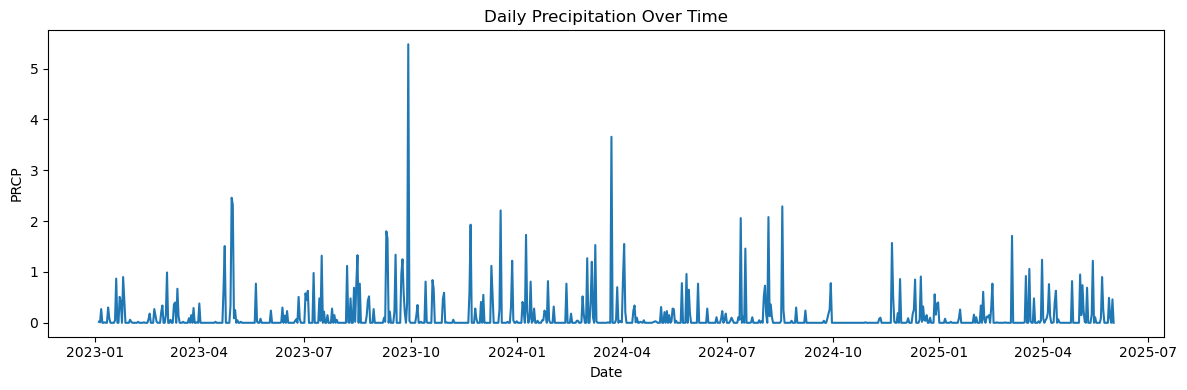

In [28]:
# 12. Time series plot of PRCP over time
plt.figure(figsize=(12, 4))
sns.lineplot(x="DATE", y="PRCP", data=df)
plt.title("Daily Precipitation Over Time")
plt.xlabel("Date")
plt.ylabel("PRCP")
plt.tight_layout()

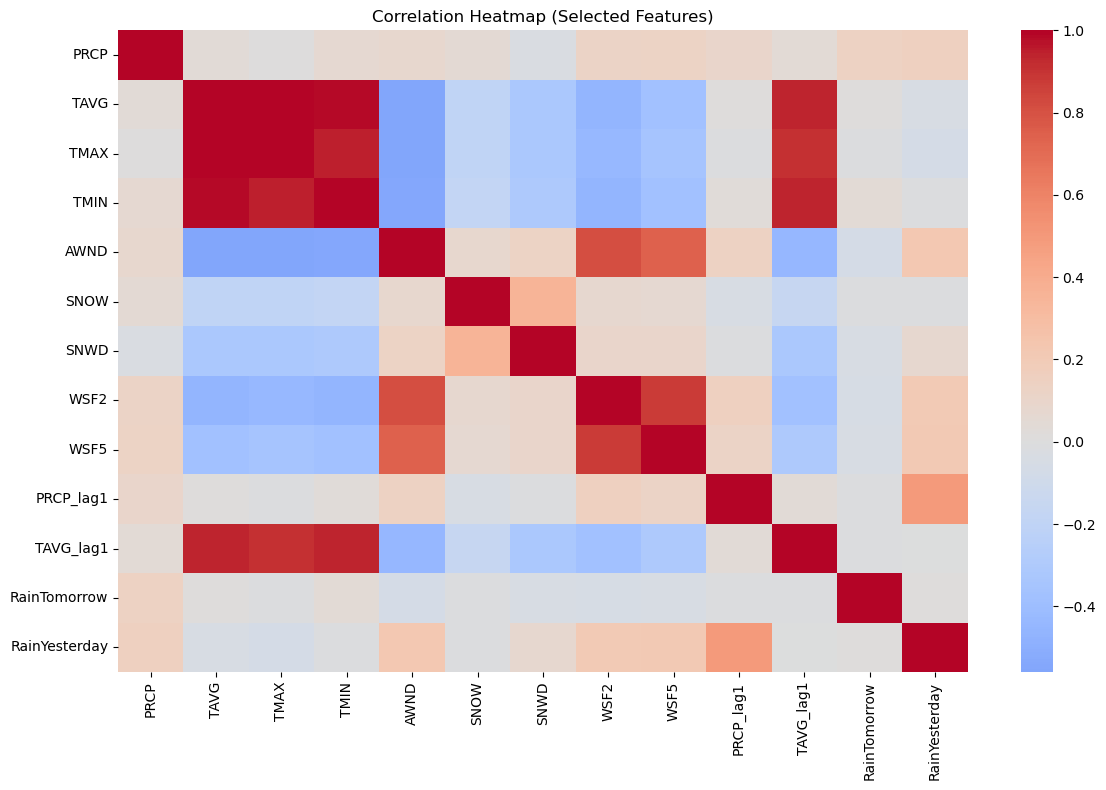

In [29]:
# SECTION 4: Correlation & Lag Features

# 13. Correlation heatmap for selected numeric columns
corr_cols = [
    "PRCP","TAVG","TMAX","TMIN","AWND",
    "SNOW","SNWD","WSF2","WSF5",
    "PRCP_lag1","TAVG_lag1",
    "RainToday","RainTomorrow","RainYesterday"
]
corr_cols = [c for c in corr_cols if c in df.columns]

plt.figure(figsize=(12, 8))
sns.heatmap(df[corr_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Selected Features)")
plt.tight_layout()

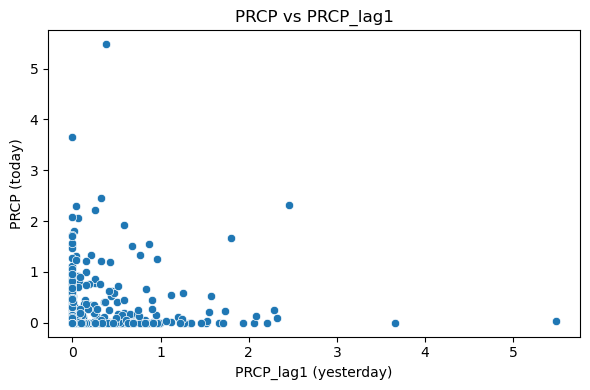

In [30]:
# 14. Scatter plot: PRCP vs PRCP_lag1

plt.figure(figsize=(6, 4))
sns.scatterplot(x="PRCP_lag1", y="PRCP", data=df)
plt.title("PRCP vs PRCP_lag1")
plt.xlabel("PRCP_lag1 (yesterday)")
plt.ylabel("PRCP (today)")
plt.tight_layout()

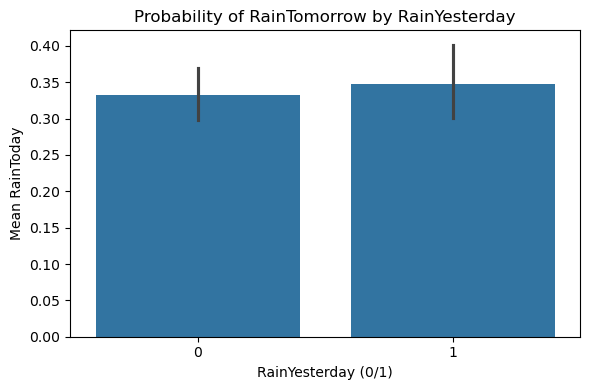

In [31]:
# 15. RainToday vs RainYesterday

plt.figure(figsize=(6, 4))
sns.barplot(x="RainYesterday", y="RainTomorrow", data=df, estimator=np.mean)
plt.title("Probability of RainTomorrow by RainYesterday")
plt.xlabel("RainYesterday (0/1)")
plt.ylabel("Mean RainToday")
plt.tight_layout()

## STEP 4 — Train Models
Train Logistic Regression (L1, L2), Random Forest, Bagging, AdaBoost, Gradient Boosting

## Grid Search for Random Forest
Optimize hyperparameters using 5-fold cross-validation for best performance.

## Evaluate Models Silently
Compute Accuracy, Precision, Recall, F1-score, and AUC without printing or plotting.

## Compile Results
Create a DataFrame with evaluation metrics for all models, sorted by AUC.


In [33]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# 0) Metric preference
# In rainfall prediction, missing rain (FN) is often more costly than a false alarm (FP),
# so we prioritize RECALL.

METRIC_PREFERENCE = "recall"

def pick_primary_score(row):
    return row["recall"] if METRIC_PREFERENCE == "recall" else row["precision"]

feature_cols = [
    "PRCP", "TAVG", "TMAX", "TMIN", "AWND",
    "SNOW", "SNWD", "WDF2", "WDF5", "WSF2", "WSF5",
    "WT01", "WT02", "WT03", "WT04", "WT05",
    "Month", "DayOfYear",
    "PRCP_lag1", "TAVG_lag1", "RainYesterday"
]

TARGET = "RainTomorrow"

X = df[feature_cols].copy()
y = df[TARGET].astype(int).copy()

In [34]:
# 2) Train/Test Split
# keep shuffle=False because this is time-ordered daily data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    shuffle=False
)

# 3) Models

models = {}

# (A) Logistic Regression baseline
models["LogReg_L2"] = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(penalty="l2", solver="liblinear", max_iter=2000, random_state=42))
])

models["LogReg_L1"] = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(penalty="l1", solver="liblinear", max_iter=2000, random_state=42))
])

In [35]:
# (B) Decision Tree baseline
models["DecisionTree"] = DecisionTreeClassifier(
    max_depth=6,              # simple control against overfitting
    min_samples_leaf=20,
    random_state=42
)

# (C) Random Forest
models["RandomForest"] = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

In [36]:
# 4) Fit + Evaluate
def eval_model(model, X_tr, y_tr, X_te, y_te, threshold=0.5):
    model.fit(X_tr, y_tr)

    # Predict probabilities if possible
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        # fallback (rare here)
        y_prob = model.decision_function(X_te)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-9)

    y_pred = (y_prob >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
        "auc": roc_auc_score(y_te, y_prob),
        "threshold": threshold
    }

from sklearn.metrics import confusion_matrix, RocCurveDisplay

def plot_confusion_matrix(y_true, y_pred, title):
    plt.figure(figsize=(6, 5))

    cm = confusion_matrix(y_true, y_pred)

    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0, 1], ["0", "1"])
    plt.yticks([0, 1], ["0", "1"])

    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_roc_curve(y_true, y_prob, title):
    plt.figure(figsize=(6, 5))

    RocCurveDisplay.from_predictions(y_true, y_prob)
    plt.plot([0, 1], [0, 1], "r--", label="Random (AUC = 0.5)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()


In [37]:
def predict_proba_any(model, X_te):
    """Return probability for class 1."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_te)[:, 1]
    # fallback for models without predict_proba
    scores = model.decision_function(X_te)
    scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    return scores


def evaluate_and_plot(model, X_tr, y_tr, X_te, y_te, name, threshold=0.5):
    model.fit(X_tr, y_tr)

    y_prob = predict_proba_any(model, X_te)
    y_pred = (y_prob >= threshold).astype(int)

    plot_confusion_matrix(y_te, y_pred, title=f"{name} — Confusion Matrix (thr={threshold})")
    plot_roc_curve(y_te, y_prob, title=f"{name} — ROC Curve")

    return y_pred, y_prob

In [38]:
# 5) Choose threshold consistent with metric preference
# If we prioritize recall, we often lower threshold a bit; if precision, raise it.

THRESHOLD = 0.40 if METRIC_PREFERENCE == "recall" else 0.60

results = []
for name, model in models.items():
    m = eval_model(model, X_train, y_train, X_test, y_test, threshold=THRESHOLD)
    m["model"] = name
    results.append(m)

results_df = pd.DataFrame(results).set_index("model")
results_df["primary_metric"] = results_df.apply(pick_primary_score, axis=1)

# Nice ordering for report/table
results_df = results_df[["accuracy", "precision", "recall", "f1", "auc", "threshold", "primary_metric"]] \
    .sort_values(by=["primary_metric", "auc"], ascending=False)

print(f"Metric preference = {METRIC_PREFERENCE.upper()}  |  threshold = {THRESHOLD}")
results_df.round(4)

Metric preference = RECALL  |  threshold = 0.4


,accuracy,precision,recall,f1,auc,threshold,primary_metric
model,,,,,,,
RandomForest,0.6318,0.4677,0.3766,0.4173,0.5989,0.4,0.3766
LogReg_L2,0.6500,0.5000,0.2468,0.3304,0.6038,0.4,0.2468
LogReg_L1,0.6500,0.5000,0.2468,0.3304,0.6035,0.4,0.2468
DecisionTree,0.5955,0.3750,0.2338,0.2880,0.5316,0.4,0.2338


In [39]:
# Source - https://stackoverflow.com/a
# Posted by Sam Van Kooten, modified by community. See post 'Timeline' for change history
# Retrieved 2025-12-14, License - CC BY-SA 4.0

from IPython.display import display, HTML
display(HTML("<style>.jp-CodeCell.jp-mod-outputsScrolled .jp-Cell-outputArea { max-height: 44em; }</style>"))


=== LogReg_L2 ===


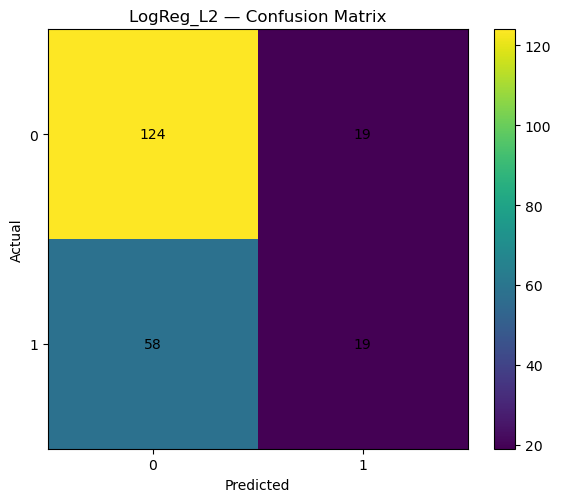

<Figure size 600x500 with 0 Axes>

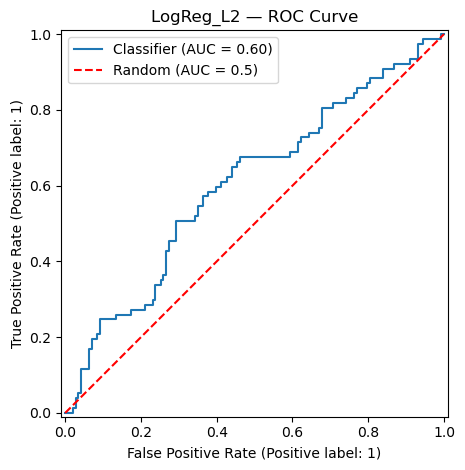


=== LogReg_L1 ===


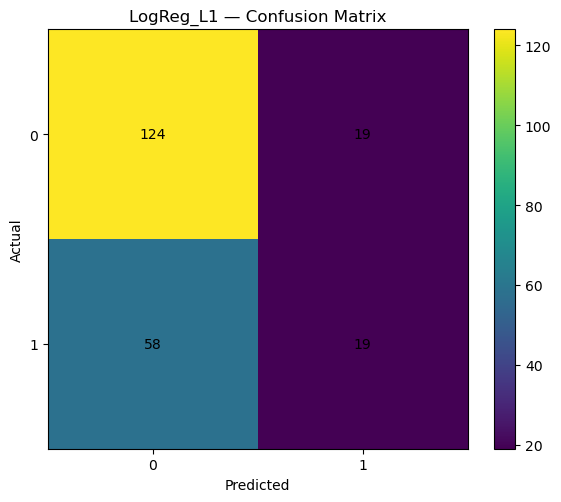

<Figure size 600x500 with 0 Axes>

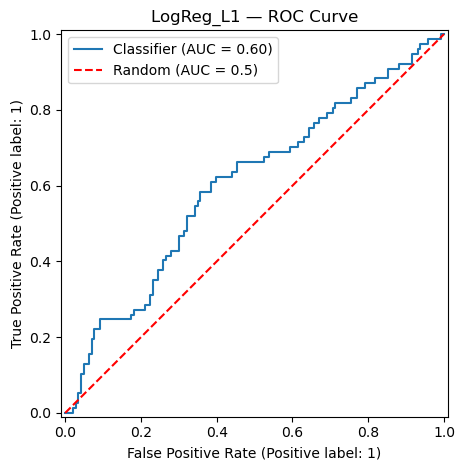


=== DecisionTree ===


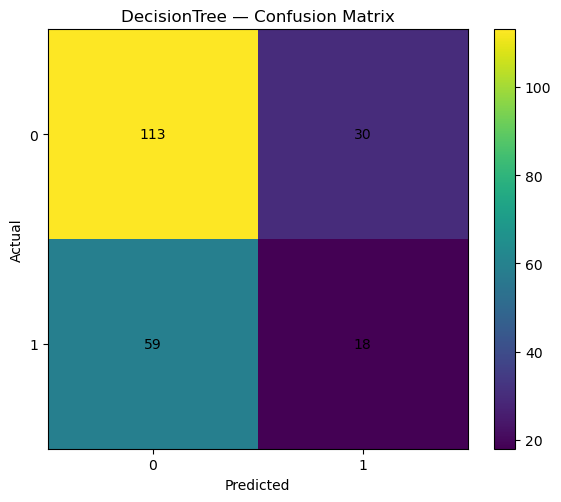

<Figure size 600x500 with 0 Axes>

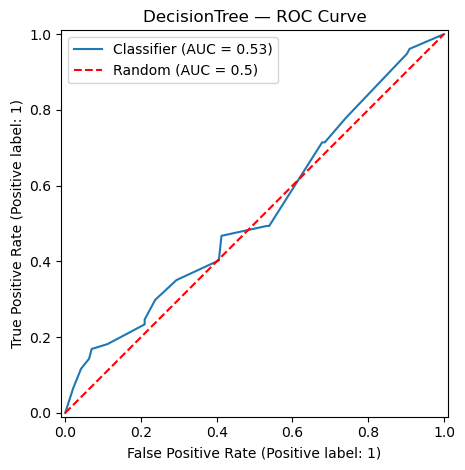


=== RandomForest ===


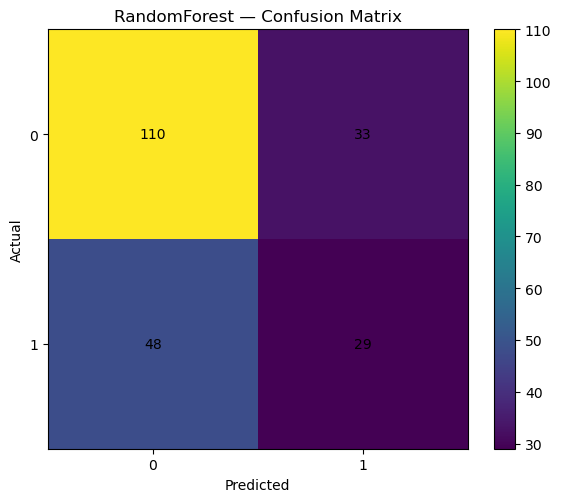

<Figure size 600x500 with 0 Axes>

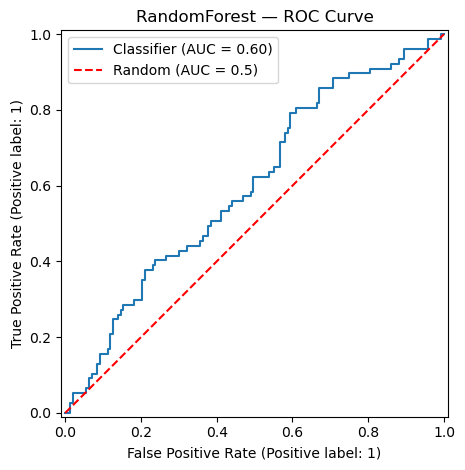

In [40]:
for name, model in models.items():
    print(f"\n=== {name} ===")

    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        scores = model.decision_function(X_test)
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

    y_pred = (y_prob >= THRESHOLD).astype(int)

    plot_confusion_matrix(
        y_test,
        y_pred,
        title=f"{name} — Confusion Matrix"
    )

    plot_roc_curve(
        y_test,
        y_prob,
        title=f"{name} — ROC Curve"
    )


In [41]:
# 6) Cross-validation + (light) GridSearch for RF

tscv = TimeSeriesSplit(n_splits=5)

rf_param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [8, 10, 12],
    "min_samples_leaf": [1, 3, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print("\n=== Cross-Validation (TimeSeriesSplit) — Best RF Params ===")
print(rf_grid.best_params_)
print(f"Best CV AUC: {rf_grid.best_score_:.4f}")


=== Cross-Validation (TimeSeriesSplit) — Best RF Params ===
{'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 500}
Best CV AUC: 0.6645



--- Plotting for: RandomForest_CV_Best ---


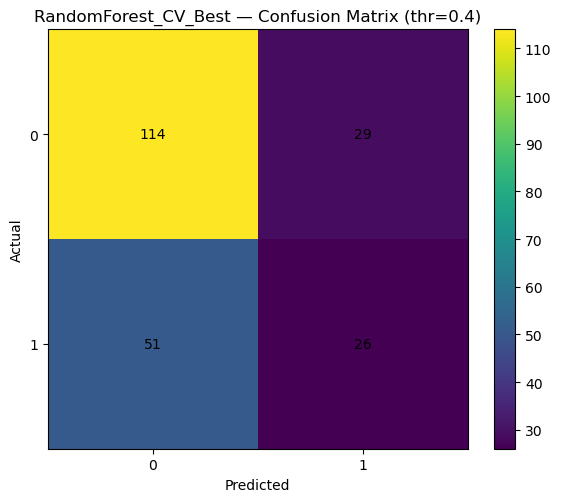

<Figure size 600x500 with 0 Axes>

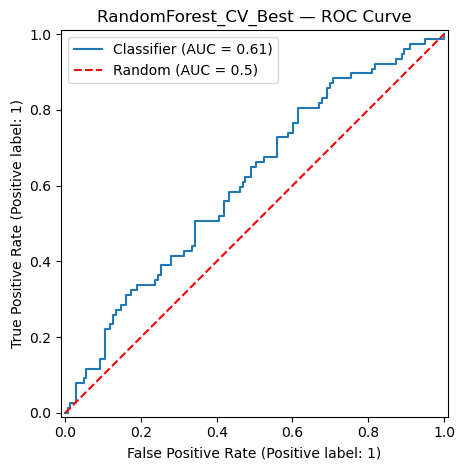

In [42]:
print("\n--- Plotting for: RandomForest_CV_Best ---")
_ = evaluate_and_plot(
    best_rf,
    X_train, y_train,
    X_test, y_test,
    name="RandomForest_CV_Best",
    threshold=THRESHOLD
)

In [43]:
# Evaluate best_rf on test using SAME threshold rule
best_rf_metrics = eval_model(best_rf, X_train, y_train, X_test, y_test, threshold=THRESHOLD)
print("\n=== Best RF (GridSearchCV) — Test Metrics ===")
print({k: round(v, 4) if isinstance(v, float) else v for k, v in best_rf_metrics.items()})

# Add to comparison table
best_row = pd.Series({
    "accuracy": best_rf_metrics["accuracy"],
    "precision": best_rf_metrics["precision"],
    "recall": best_rf_metrics["recall"],
    "f1": best_rf_metrics["f1"],
    "auc": best_rf_metrics["auc"],
    "threshold": best_rf_metrics["threshold"],
    "primary_metric": best_rf_metrics["recall"] if METRIC_PREFERENCE == "recall" else best_rf_metrics["precision"]
}, name="RandomForest_CV_Best")

results_df_plus = pd.concat([results_df, best_row.to_frame().T], axis=0) \
    .sort_values(by=["primary_metric", "auc"], ascending=False)

print("\n=== Model Comparison Table (+ Best RF from CV) ===")
results_df_plus.round(4)


=== Best RF (GridSearchCV) — Test Metrics ===
{'accuracy': 0.6364, 'precision': 0.4727, 'recall': 0.3377, 'f1': 0.3939, 'auc': 0.6077, 'threshold': 0.4}

=== Model Comparison Table (+ Best RF from CV) ===


,accuracy,precision,recall,f1,auc,threshold,primary_metric
RandomForest,0.6318,0.4677,0.3766,0.4173,0.5989,0.4,0.3766
RandomForest_CV_Best,0.6364,0.4727,0.3377,0.3939,0.6077,0.4,0.3377
LogReg_L2,0.6500,0.5000,0.2468,0.3304,0.6038,0.4,0.2468
LogReg_L1,0.6500,0.5000,0.2468,0.3304,0.6035,0.4,0.2468
DecisionTree,0.5955,0.3750,0.2338,0.2880,0.5316,0.4,0.2338


In [44]:
def plot_tree_feature_importance(model, feature_names, top_k=15, title="Feature Importance"):
    """
    Works for DecisionTreeClassifier and RandomForestClassifier
    """
    imp = pd.Series(model.feature_importances_, index=feature_names) \
            .sort_values(ascending=False)

    plt.figure(figsize=(8, 6))
    imp.head(top_k).sort_values().plot(kind="barh")
    plt.title(f"{title} (Top {top_k})")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    # return full importance table for report
    return imp


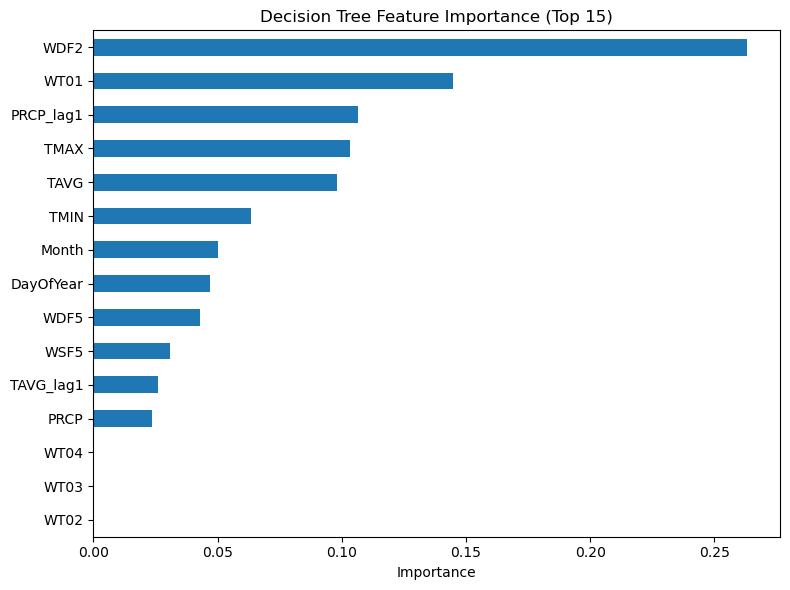


Decision Tree — Top 15 Features
  feature  importance
     WDF2    0.263252
     WT01    0.144785
PRCP_lag1    0.106581
     TMAX    0.103171
     TAVG    0.098084
     TMIN    0.063564
    Month    0.050271
DayOfYear    0.047092
     WDF5    0.042927
     WSF5    0.030783
TAVG_lag1    0.025983
     PRCP    0.023506
     WT02    0.000000
     WT03    0.000000
     WT04    0.000000


In [45]:
dt_model = models["DecisionTree"]

dt_importance = plot_tree_feature_importance(
    dt_model,
    feature_cols,
    top_k=15,
    title="Decision Tree Feature Importance"
)

dt_top15 = dt_importance.head(15).reset_index()
dt_top15.columns = ["feature", "importance"]
print("\nDecision Tree — Top 15 Features")
print(dt_top15.to_string(index=False))

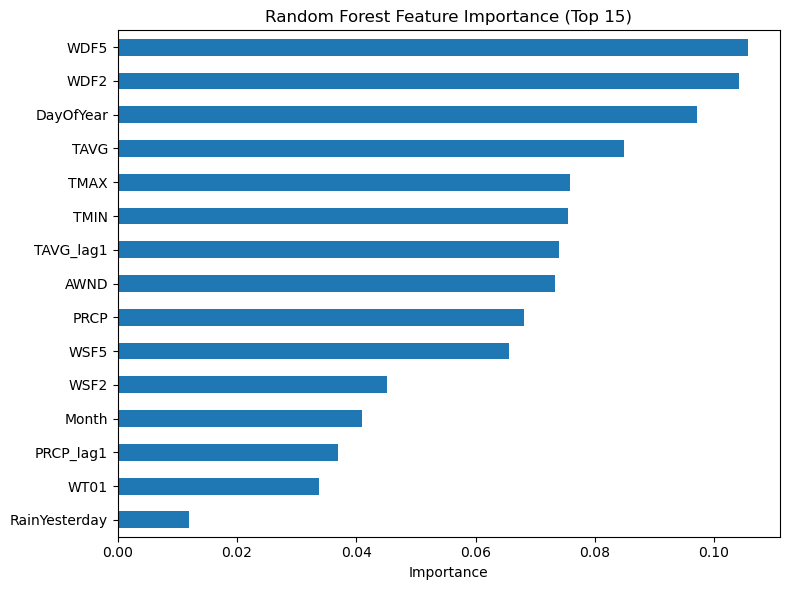


Random Forest — Top 15 Features
      feature  importance
         WDF5    0.105771
         WDF2    0.104137
    DayOfYear    0.097116
         TAVG    0.084978
         TMAX    0.075915
         TMIN    0.075553
    TAVG_lag1    0.073915
         AWND    0.073324
         PRCP    0.068153
         WSF5    0.065567
         WSF2    0.045220
        Month    0.040875
    PRCP_lag1    0.036851
         WT01    0.033728
RainYesterday    0.011932


In [46]:
rf_model = models["RandomForest"]

rf_importance = plot_tree_feature_importance(
    rf_model,
    feature_cols,
    top_k=15,
    title="Random Forest Feature Importance"
)

rf_top15 = rf_importance.head(15).reset_index()
rf_top15.columns = ["feature", "importance"]
print("\nRandom Forest — Top 15 Features")
print(rf_top15.to_string(index=False))

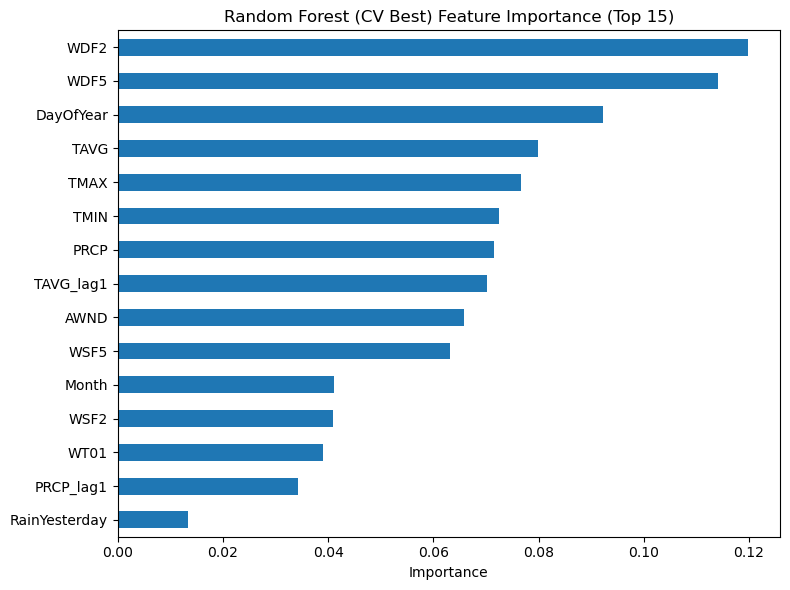


Random Forest (CV Best) — Top 15 Features
      feature  importance
         WDF2    0.119907
         WDF5    0.114085
    DayOfYear    0.092328
         TAVG    0.079966
         TMAX    0.076570
         TMIN    0.072488
         PRCP    0.071503
    TAVG_lag1    0.070115
         AWND    0.065866
         WSF5    0.063172
        Month    0.041173
         WSF2    0.040924
         WT01    0.039103
    PRCP_lag1    0.034190
RainYesterday    0.013254


In [47]:
rf_importance_cv = plot_tree_feature_importance(
    best_rf,
    feature_cols,
    top_k=15,
    title="Random Forest (CV Best) Feature Importance"
)

rf_top15_cv = rf_importance_cv.head(15).reset_index()
rf_top15_cv.columns = ["feature", "importance"]
print("\nRandom Forest (CV Best) — Top 15 Features")
print(rf_top15_cv.to_string(index=False))


In [48]:
rf_model = best_rf

# Extract Top 5 Features

import pandas as pd

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

top5_features = rf_importance.head(5).index.tolist()

print("Top 5 Features used for robustness check:")
for f in top5_features:
    print("-", f)


Top 5 Features used for robustness check:
- WDF2
- WDF5
- DayOfYear
- TAVG
- TMAX


In [49]:
X_train_top5 = X_train[top5_features]
X_test_top5  = X_test[top5_features]

rf_simplified = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_simplified.fit(X_train_top5, y_train)

RandomForestClassifier(max_depth=8, min_samples_leaf=3, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [50]:
def eval_rf_simple(model, X_te, y_te, threshold):
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
        "auc": roc_auc_score(y_te, y_prob)
    }

simplified_metrics = eval_rf_simple(
    rf_simplified,
    X_test_top5,
    y_test,
    threshold=THRESHOLD
)

print("\nSimplified RF (Top 5 features) — Test Performance")
for k, v in simplified_metrics.items():
    print(f"{k}: {v:.4f}")


Simplified RF (Top 5 features) — Test Performance
accuracy: 0.6227
precision: 0.4516
recall: 0.3636
f1: 0.4029
auc: 0.5905


In [51]:
full_rf_metrics = results_df.loc["RandomForest", ["accuracy", "precision", "recall", "f1", "auc"]]

comparison = pd.DataFrame({
    "Full RF (All Features)": full_rf_metrics,
    "Simplified RF (Top 5)": pd.Series(simplified_metrics)
})

print("\n=== Robustness Check: Full RF vs Simplified RF ===")
comparison.round(4)



=== Robustness Check: Full RF vs Simplified RF ===


,Full RF (All Features),Simplified RF (Top 5)
accuracy,0.6318,0.6227
precision,0.4677,0.4516
recall,0.3766,0.3636
f1,0.4173,0.4029
auc,0.5989,0.5905



--- Simplified RF (Top 5) — Plots ---


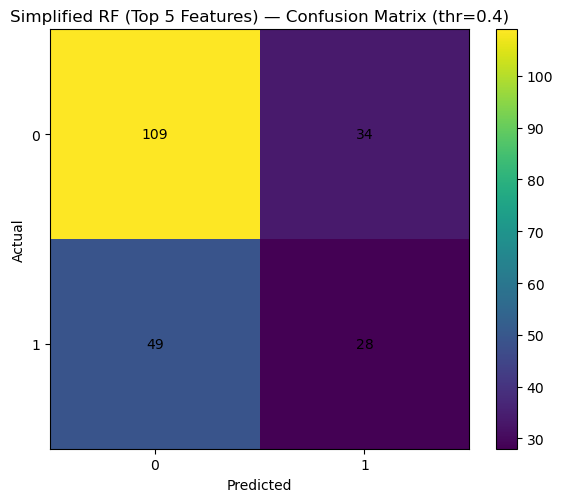

<Figure size 600x500 with 0 Axes>

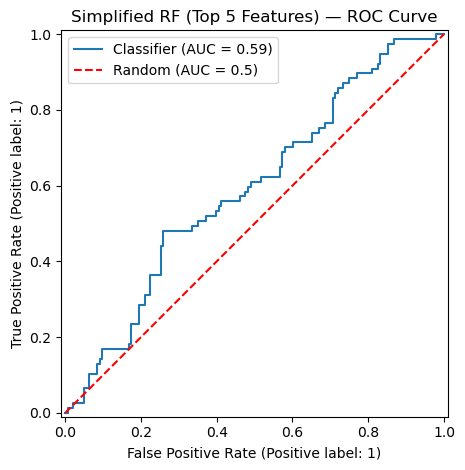

In [52]:
print("\n--- Simplified RF (Top 5) — Plots ---")
_ = evaluate_and_plot(
    rf_simplified,
    X_train_top5, y_train,
    X_test_top5, y_test,
    name="Simplified RF (Top 5 Features)",
    threshold=THRESHOLD
)